In [2]:
# ── Cell 1: Load and prepare data ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./results/results.csv")

# Per-entry absolute error (recomputed here rather than stored, so you can
# change the error metric later without re-running the experiment)
df["err_00"] = (df["beta_est_00"] - df["beta_true_00"]).abs()
df["err_01"] = (df["beta_est_01"] - df["beta_true_01"]).abs()
df["err_11"] = (df["beta_est_11"] - df["beta_true_11"]).abs()

# Overall per-row error summary (mean across the 3 unique entries)
df["mae"] = df[["err_00", "err_01", "err_11"]].mean(axis=1)

# inter-block error is usually the more interesting/harder one (smaller true value)
df["inter_err"] = df["err_01"]
# intra-block error, averaged over the two diagonal entries
df["intra_err"] = df[["err_00", "err_11"]].mean(axis=1)

print(f"Total rows: {len(df)}")
print(f"N values: {sorted(df['N'].unique())}")
print(f"sigma values: {sorted(df['sigma'].unique())}")
print(f"methods: {df['method'].unique()}")
df.head()

Total rows: 900
N values: [100, 200, 500]
sigma values: [1.0, 2.0, 5.0, 10.0, 20.0]
methods: ['sbm_dpsgd' 'gaussian' 'edge_flip']


,N,sigma,epsilon,delta,method,rep,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,err_00,err_01,err_11,mae,inter_err,intra_err
0,100,1.0,5.635918,0.00001,sbm_dpsgd,0,0.2,0.02,0.2,0.224630,0.025007,0.211275,0.024630,0.005007,0.011275,0.013637,0.005007,0.017952
1,100,1.0,5.635918,0.00001,gaussian,0,0.2,0.02,0.2,0.210248,0.013290,0.195939,0.010248,0.006710,0.004061,0.007006,0.006710,0.007154
2,100,1.0,5.635918,0.00001,edge_flip,0,0.2,0.02,0.2,0.208540,0.013340,0.201963,0.008540,0.006660,0.001963,0.005721,0.006660,0.005251
3,100,1.0,5.635918,0.00001,sbm_dpsgd,1,0.2,0.02,0.2,0.206864,0.034529,0.236614,0.006864,0.014529,0.036614,0.019336,0.014529,0.021739
4,100,1.0,5.635918,0.00001,gaussian,1,0.2,0.02,0.2,0.210118,0.016762,0.218588,0.010118,0.003238,0.018588,0.010648,0.003238,0.014353


In [3]:
# ── Cell 2: Epsilon actually achieved per (N, sigma) ─────────────────────────
# Since epsilon is derived from sigma (SBM accountant) and shared across all
# 3 methods at that N, this is just a lookup table for reference.
eps_table = (
    df[["N", "sigma", "epsilon"]]
    .drop_duplicates()
    .sort_values(["N", "sigma"])
    .reset_index(drop=True)
)
eps_table

,N,sigma,epsilon
0,100,1.0,5.635918
1,100,2.0,2.668103
2,100,5.0,1.033895
3,100,10.0,0.543112
4,100,20.0,0.405612
5,200,1.0,5.635918
6,200,2.0,2.668103
7,200,5.0,1.033895
8,200,10.0,0.543112
9,200,20.0,0.405612


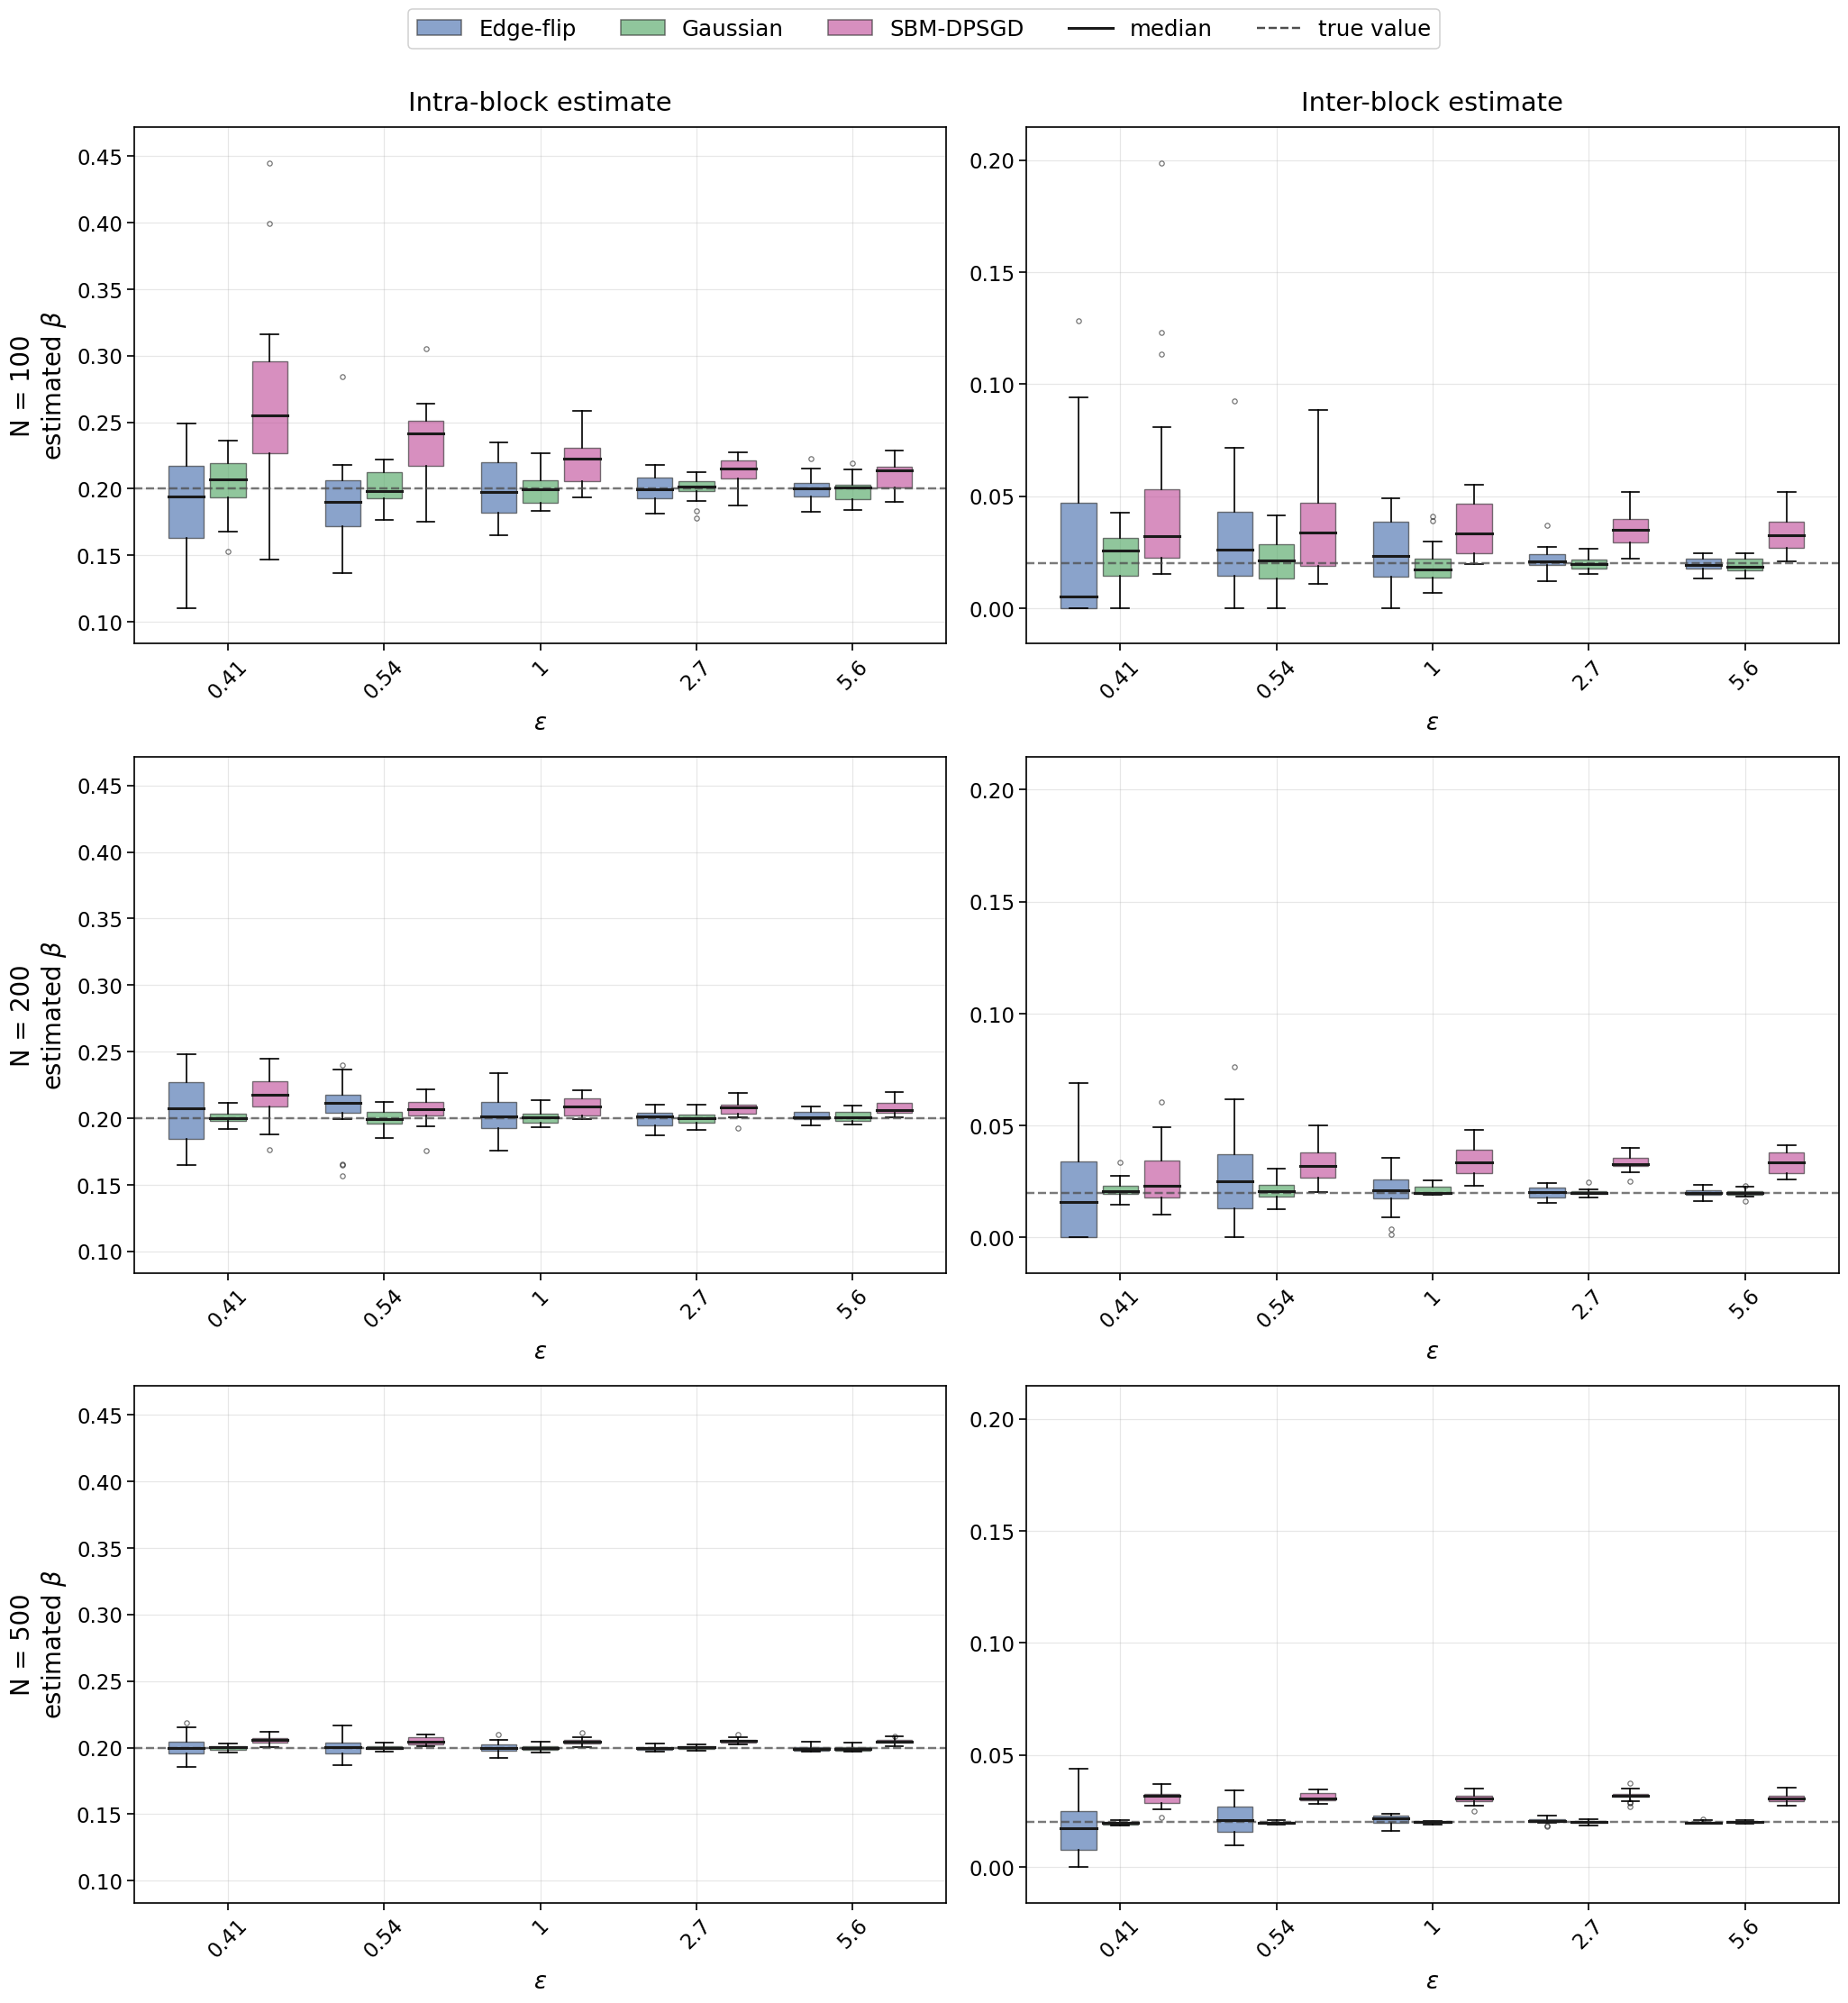

In [4]:
# ── Cell 3: Boxplots of estimated beta vs epsilon ───────────────────────────
# Layout: one ROW per N, two COLUMNS (intra-block, inter-block). Six large
# panels instead of the old 6-wide grid -- sized for a full-page thesis figure,
# so each panel survives being scaled down in LaTeX.
#
# Shared scales: both panels in the LEFT column share one y-limit and both in
# the RIGHT column share another, so N-to-N comparisons down a column are
# honest. Intra and inter are NOT put on a common scale -- the true values
# differ by 10x (0.2 vs 0.02) and a shared axis would flatten the inter column.
#
# Colours/labels/median style come from plot_style.py so every figure in the
# thesis uses the same colour for the same method.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()

Ns = sorted(df["N"].unique())
methods = order_methods(df["method"].unique())

# One panel is ~7 x 5 inches before FIG_SCALE; with 3 N values that is a tall
# full-page figure. Change PANEL_W / PANEL_H to retune.
PANEL_W, PANEL_H = 7.0, 5.0

fig, axes = plt.subplots(
    len(Ns), 2,
    figsize=figsize(PANEL_W * 2, PANEL_H * len(Ns)),
    squeeze=False,
)

# ── precompute per-column y-limits (shared down each column) ────────────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

COLUMNS = [
    ("intra_est",   "beta_true_00", "Intra-block estimate", pad(intra_ymin, intra_ymax)),
    ("beta_est_01", "beta_true_01", "Inter-block estimate", pad(inter_ymin, inter_ymax)),
]

for row, N in enumerate(Ns):
    sub = df[df["N"] == N].copy()
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    for col, (est_col, true_col, col_title, ylim) in enumerate(COLUMNS):
        ax = axes[row, col]
        grouped_boxplot(ax, sub, est_col, methods=methods)
        reference_line(ax, sub[true_col].iloc[0])
        ax.set_ylim(ylim)
        ax.set_xlabel(r"$\epsilon$")
        if row == 0:
            ax.set_title(col_title, fontsize=19, pad=12)

    # N labels the row, so it is stated once on the left instead of six times
    # in six panel titles.
    axes[row, 0].set_ylabel(f"N = {N}\n" r"estimated $\beta$", fontsize=18)

# One figure-level legend: with panels this large, a per-panel legend would
# either cover data or be repeated six times.
handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [
    Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
    Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
           label="true value"),
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

: 